# Grasp adaptation — compliance-matched stiffness control

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar

OUTPUT_DIR = os.path.join('outputs', 'grasp_adaptation')
OBJECTS    = ['hard_obj', 'soft_obj']
COLORS     = {'hard_obj': '#0072B2', 'soft_obj': '#D55E00'}

def load_latest(obj):
    folder = Path(OUTPUT_DIR)
    if not folder.exists():
        return None
    files = sorted(folder.glob(f'grasp_{obj}*.csv'))
    return pd.read_csv(files[-1]) if files else None

data = {obj: load_latest(obj) for obj in OBJECTS}

## Sensing phase — fingertip displacement per object

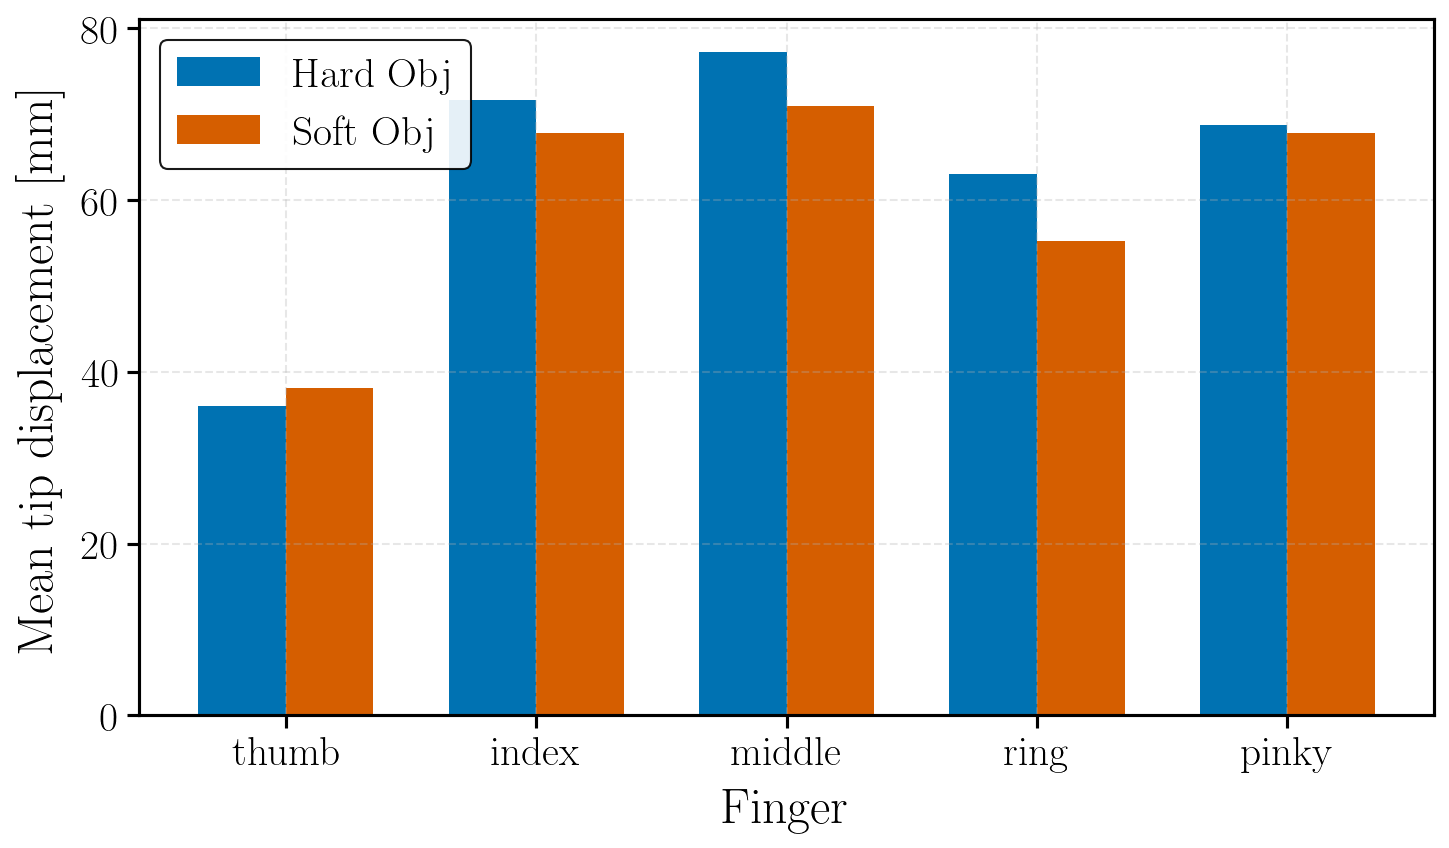

In [5]:
fig, ax = plt.subplots()

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, (obj, color) in enumerate(COLORS.items()):
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    means = [sense[f'disp_{f}_mag_m'].mean() * 1e3 for f in FINGERTIPS]
    ax.bar(x + i * width, means, width, label=obj.replace('_', ' ').title(),
           color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Mean tip displacement [mm]')
ax.legend()
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'sensing_displacement.pdf'), bbox_inches='tight')
plt.show()

## Adapted stiffness — sensing displacement vs k_applied

KeyError: 'K_GAIN'

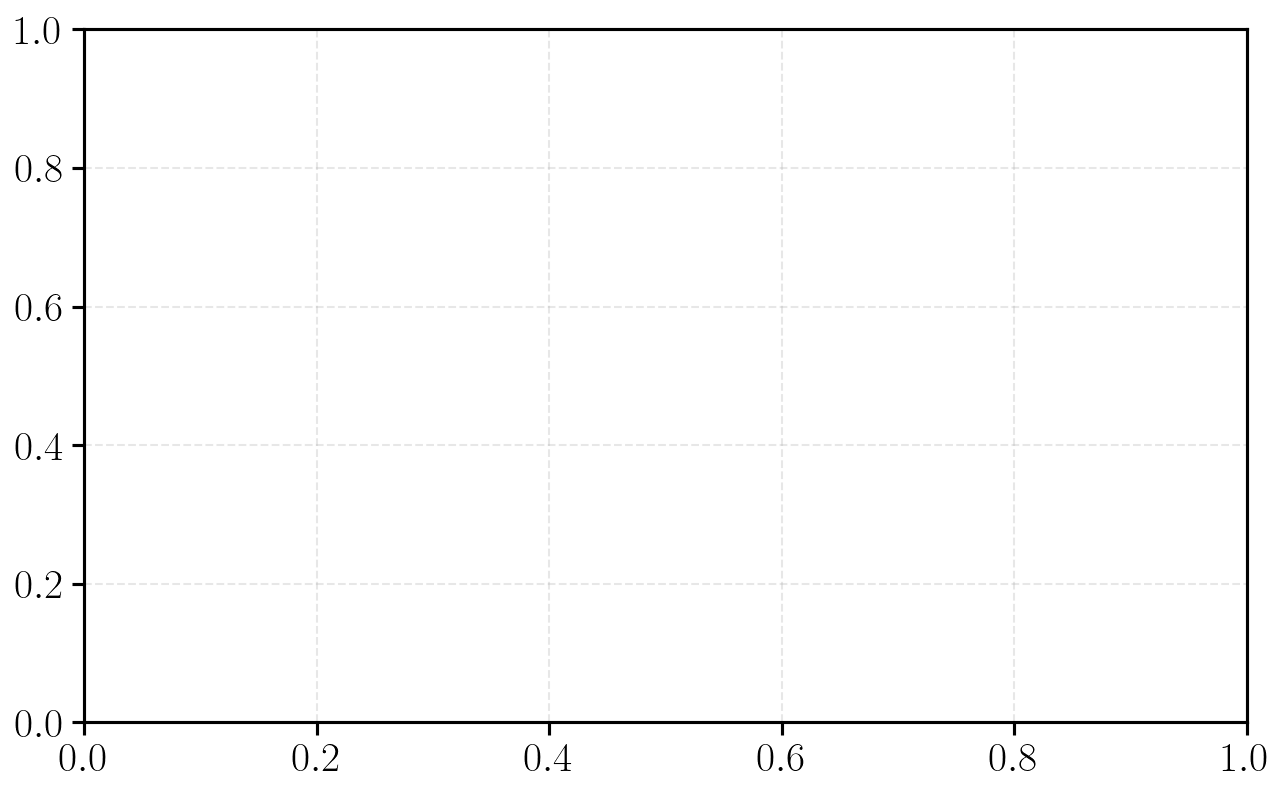

In [ ]:
fig, ax = plt.subplots()

# Overlay the adaptation curve k = K_GAIN / delta (clipped to [K_MIN, K_MAX]).
_ns = {}
with open('grasp_adaptation.py') as _f:
    for _line in _f:
        if _line.startswith(('K_GAIN', 'K_MIN', 'K_MAX')):
            exec(_line, _ns)
K_GAIN = float(_ns['K_GAIN'])
K_MIN  = float(_ns['K_MIN'])
K_MAX  = float(_ns['K_MAX'])

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
delta_range = np.linspace(1e-4, 0.05, 300)
k_curve     = np.clip(K_GAIN / delta_range, K_MIN, K_MAX)
ax.plot(delta_range * 1e3, k_curve, color='0.5', lw=1, linestyle='--',
        label='adaptation curve')

for obj, color in COLORS.items():
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    delta = float(sense[[f'disp_{f}_mag_m' for f in FINGERTIPS]].mean(axis=1).mean()) * 1e3
    k_app = float(sense['k_applied_Npm'].iloc[-1])
    ax.scatter([delta], [k_app], color=color, zorder=5,
               label=obj.replace('_', ' ').title())
    ax.annotate(f'{k_app:.0f} N/m', (delta, k_app),
                textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('δ_mean [mm]')
ax.set_ylabel('k_applied [N/m]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'adaptation_curve.pdf'), bbox_inches='tight')
plt.show()